# Advanced Model — LSTM on BERT embeddings
Train and evaluate an LSTM-based classifier using precomputed BERT embeddings.

**Goals**
- Load BERT embeddings and labels
- Split train/validation/test (70/15/15)
- Define and train an LSTM model
- Evaluate Accuracy, Precision, Recall, F1
- Save model, metrics, and predictions

In [1]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

# Imports and environment info
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('Enabled memory growth for GPUs')
    except Exception as e:
        print('Could not set memory growth:', e)
    
    try:
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision policy:', mixed_precision.global_policy().name)
    except Exception as e:
        print('Mixed precision not enabled:', e)
else:
    print('No GPUs found, running on CPU')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Enabled memory growth for GPUs
Mixed precision policy: mixed_float16


In [2]:
# Define paths based on your Google Drive shortcut structure
PROJECT_ROOT = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURE_DIR = os.path.join(PROJECT_ROOT, 'data', 'features', 'SmartReviewAnalyzer_features')

X_train_path = os.path.join(FEATURE_DIR, 'X_train_bert.npy')
X_test_path = os.path.join(FEATURE_DIR, 'X_test_bert.npy')
labels_path = os.path.join(PROJECT_ROOT, 'data', 'features', 'labels.npz')

print('Loading from:', X_train_path)
print('Loading from:', X_test_path)
print('Loading from:', labels_path)

X_train = np.load(X_train_path, allow_pickle=True)
X_test = np.load(X_test_path, allow_pickle=True)
labels_npz = np.load(labels_path, allow_pickle=True)
print('labels keys:', labels_npz.files)

# Infer train/test labels from the .npz (robust handling)
if 'y_train' in labels_npz.files and 'y_test' in labels_npz.files:
    y_train = labels_npz['y_train']
    y_test = labels_npz['y_test']
elif 'y' in labels_npz.files:
    y_all = labels_npz['y']
    if len(y_all) == len(X_train) + len(X_test):
        y_train = y_all[:len(X_train)]
        y_test = y_all[len(X_train):]
    else:
        raise ValueError("labels.npz contains 'y' but length mismatch with X arrays")
else:
    files = labels_npz.files
    if len(files) >= 2:
        y_train = labels_npz[files[0]]
        y_test = labels_npz[files[1]]
    else:
        raise ValueError('Unable to infer train/test labels from labels.npz')

print('Shapes before split: X_train', X_train.shape, 'X_test', X_test.shape, 'y_train', y_train.shape, 'y_test', y_test.shape)

# Carve validation (15% overall) from the training set
val_fraction_of_train = 0.15 / (1 - 0.15)
print('Validation fraction of training set:', val_fraction_of_train)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_fraction_of_train, random_state=42, stratify=y_train)
print('Shapes after carve:', 'X_train', X_train.shape, 'X_val', X_val.shape, 'X_test', X_test.shape)

# Ensure inputs are 3D (samples, timesteps, features) for LSTM
def ensure_3d(arr):
    if arr.ndim == 2:
        return np.expand_dims(arr, axis=1)
    elif arr.ndim == 3:
        return arr
    else:
        raise ValueError(f'Unexpected array dimensionality: {arr.ndim}')

X_train = ensure_3d(X_train)
X_val = ensure_3d(X_val)
X_test = ensure_3d(X_test)
print('Final input shapes:', X_train.shape, X_val.shape, X_test.shape)

Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/SmartReviewAnalyzer_features/X_train_bert.npy
Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/SmartReviewAnalyzer_features/X_test_bert.npy
Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/labels.npz
labels keys: ['y_train', 'y_test']
Shapes before split: X_train (519575, 384) X_test (39972, 384) y_train (519575,) y_test (39972,)
Validation fraction of training set: 0.17647058823529413
Shapes after carve: X_train (427885, 384) X_val (91690, 384) X_test (39972, 384)
Final input shapes: (427885, 1, 384) (91690, 1, 384) (39972, 1, 384)


## Data loading and setup
Load BERT embeddings and labels, then create the 70/15/15 splits.
Note: validation is carved out from the provided training set.

In [3]:
# Define paths based on your Google Drive shortcut structure
PROJECT_ROOT = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURE_DIR = os.path.join(PROJECT_ROOT, 'data', 'features', 'SmartReviewAnalyzer_features')

X_train_path = os.path.join(FEATURE_DIR, 'X_train_bert.npy')
X_test_path = os.path.join(FEATURE_DIR, 'X_test_bert.npy')
labels_path = os.path.join(PROJECT_ROOT, 'data', 'features', 'labels.npz')

print('Loading from:', X_train_path)
print('Loading from:', X_test_path)
print('Loading from:', labels_path)

X_train = np.load(X_train_path, allow_pickle=True)
X_test = np.load(X_test_path, allow_pickle=True)
labels_npz = np.load(labels_path, allow_pickle=True)
print('labels keys:', labels_npz.files)

# Infer train/test labels from the .npz (robust handling)
if 'y_train' in labels_npz.files and 'y_test' in labels_npz.files:
    y_train = labels_npz['y_train']
    y_test = labels_npz['y_test']
elif 'y' in labels_npz.files:
    y_all = labels_npz['y']
    if len(y_all) == len(X_train) + len(X_test):
        y_train = y_all[:len(X_train)]
        y_test = y_all[len(X_train):]
    else:
        raise ValueError("labels.npz contains 'y' but length mismatch with X arrays")
else:
    files = labels_npz.files
    if len(files) >= 2:
        y_train = labels_npz[files[0]]
        y_test = labels_npz[files[1]]
    else:
        raise ValueError('Unable to infer train/test labels from labels.npz')

print('Shapes before split: X_train', X_train.shape, 'X_test', X_test.shape, 'y_train', y_train.shape, 'y_test', y_test.shape)

# Carve validation (15% overall) from the training set
val_fraction_of_train = 0.15 / (1 - 0.15)
print('Validation fraction of training set:', val_fraction_of_train)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_fraction_of_train, random_state=42, stratify=y_train)
print('Shapes after carve:', 'X_train', X_train.shape, 'X_val', X_val.shape, 'X_test', X_test.shape)

# Ensure inputs are 3D (samples, timesteps, features) for LSTM
def ensure_3d(arr):
    if arr.ndim == 2:
        return np.expand_dims(arr, axis=1)
    elif arr.ndim == 3:
        return arr
    else:
        raise ValueError(f'Unexpected array dimensionality: {arr.ndim}')

X_train = ensure_3d(X_train)
X_val = ensure_3d(X_val)
X_test = ensure_3d(X_test)
print('Final input shapes:', X_train.shape, X_val.shape, X_test.shape)

Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/SmartReviewAnalyzer_features/X_train_bert.npy
Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/SmartReviewAnalyzer_features/X_test_bert.npy
Loading from: /content/drive/MyDrive/SmartReviewAnalyzer/data/features/labels.npz
labels keys: ['y_train', 'y_test']
Shapes before split: X_train (519575, 384) X_test (39972, 384) y_train (519575,) y_test (39972,)
Validation fraction of training set: 0.17647058823529413
Shapes after carve: X_train (427885, 384) X_val (91690, 384) X_test (39972, 384)
Final input shapes: (427885, 1, 384) (91690, 1, 384) (39972, 1, 384)


## Model definition
Define an LSTM model; the Input layer is created dynamically from the training embeddings.

In [4]:
# Detect number of classes and pick loss/activation accordingly
num_classes = len(np.unique(np.concatenate([y_train, y_val, y_test])))
print('Detected number of classes:', num_classes)

if num_classes == 2:
    output_units = 1
    final_activation = 'sigmoid'
    loss = 'binary_crossentropy'
else:
    output_units = num_classes
    final_activation = 'softmax'
    loss = 'sparse_categorical_crossentropy'

timesteps = X_train.shape[1]
features = X_train.shape[2]
inputs = keras.Input(shape=(timesteps, features), name='bert_embeddings')
x = layers.Masking()(inputs)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64)(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

if output_units == 1:
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
else:
    outputs = layers.Dense(output_units, activation='softmax', dtype='float32')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='advanced_lstm')
model.summary()

Detected number of classes: 2


Model: "advanced_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ bert_embeddings     │ (None, 1, 384)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 1, 384)    │          0 │ bert_embeddings[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 1, 384)    │          0 │ cast[0][0]        │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 1, 384)    │          0 │ bert_embeddings[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 1)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1, 256)    │    525,312 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 256)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     82,176 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 611,713 (2.33 MB)

 Trainable params: 611,713 (2.33 MB)

 Non-trainable params: 0 (0.00 B)

## Compile & Train
Compile the model and train using the carved validation set.

In [5]:
batch_size = 32
epochs = 20
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate=lr)

try:
    if mixed_precision.global_policy().name == 'mixed_float16':
        optimizer = mixed_precision.LossScaleOptimizer(optimizer)
        print('Wrapped optimizer with LossScaleOptimizer for mixed precision')
except Exception as e:
    print('Could not apply LossScaleOptimizer:', e)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_advanced_lstm.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=callbacks)

Wrapped optimizer with LossScaleOptimizer for mixed precision
Epoch 1/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 166s 12ms/step - accuracy: 0.8765 - loss: 0.2976 - val_accuracy: 0.8845 - val_loss: 0.2731
Epoch 2/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 157s 12ms/step - accuracy: 0.8866 - loss: 0.2712 - val_accuracy: 0.8882 - val_loss: 0.2623
Epoch 3/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 158s 12ms/step - accuracy: 0.8894 - loss: 0.2642 - val_accuracy: 0.8914 - val_loss: 0.2569
Epoch 4/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 158s 12ms/step - accuracy: 0.8919 - loss: 0.2593 - val_accuracy: 0.8918 - val_loss: 0.2540
Epoch 5/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 156s 12ms/step - accuracy: 0.8931 - loss: 0.2553 - val_accuracy: 0.8938 - val_loss: 0.2508
Epoch 6/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 159s 12ms/step - accuracy: 0.8949 - loss: 0.2519 - val_accuracy: 0.8961 - val_loss: 0.2459
Epoch 7/20
13372/13372 ━━━━━━━━━━━━━━━━━━━━ 209s 12ms/step - accuracy: 0.8964 - loss: 0.2486 - val_accuracy: 0.8977 - val_loss: 

## Metrics evaluation
Generate predictions on the test set and compute Accuracy, Precision, Recall, and F1-score.

In [6]:
# Predictions
y_test_true = y_test
y_pred_probs = model.predict(X_test, batch_size=32)

if output_units == 1:
    y_pred = (y_pred_probs.ravel() >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_probs, axis=1)

# If y_test is one-hot, convert to label indices
if hasattr(y_test_true, 'ndim') and y_test_true.ndim > 1:
    y_test_true = np.argmax(y_test_true, axis=1)

acc = accuracy_score(y_test_true, y_pred)

if output_units == 1:
    prec = precision_score(y_test_true, y_pred, zero_division=0)
    rec = recall_score(y_test_true, y_pred, zero_division=0)
    f1 = f1_score(y_test_true, y_pred, zero_division=0)
else:
    prec = precision_score(y_test_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_true, y_pred, average='weighted', zero_division=0)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-score: {f1:.4f}')

print('\nClassification report:\n')
print(classification_report(y_test_true, y_pred, zero_division=0))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Accuracy: 0.9035
Precision: 0.9073
Recall: 0.8990
F1-score: 0.9031

Classification report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     19981
           1       0.91      0.90      0.90     19991

    accuracy                           0.90     39972
   macro avg       0.90      0.90      0.90     39972
weighted avg       0.90      0.90      0.90     39972



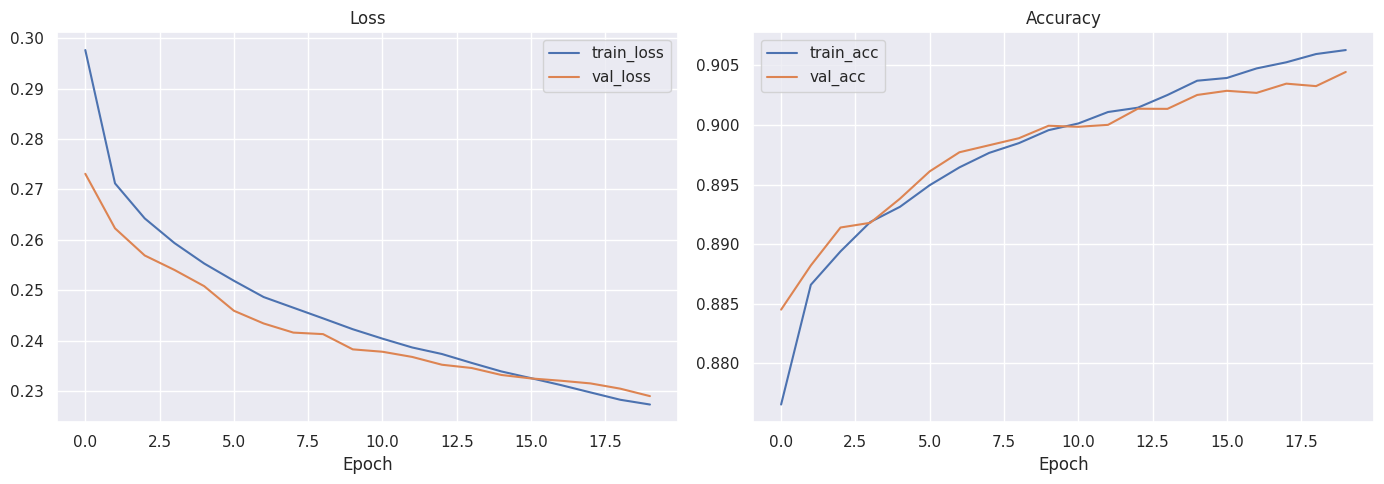

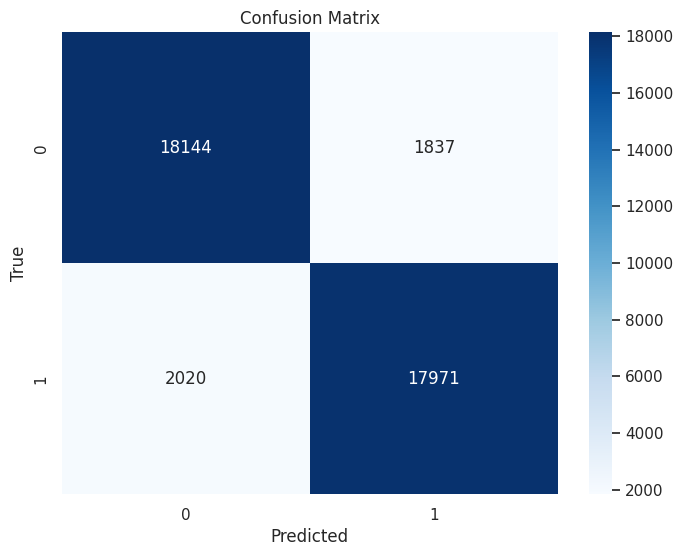

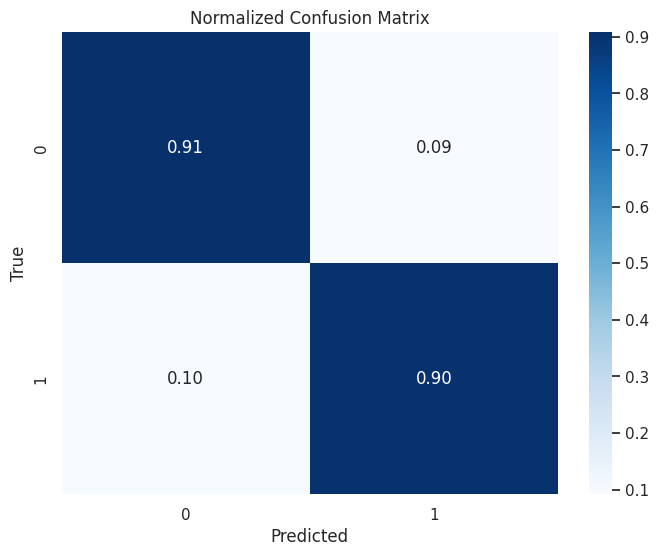

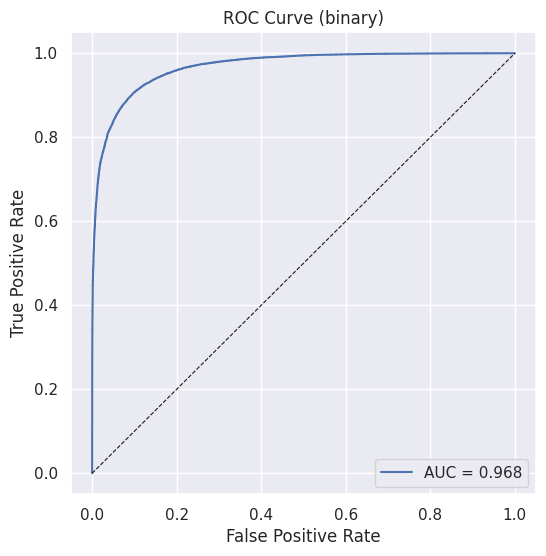

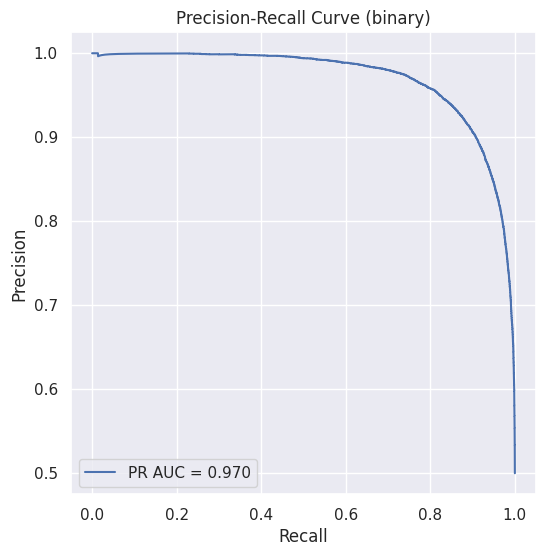

Saved predictions_vs_true.csv in /content/drive/MyDrive/SmartReviewAnalyzer/evaluation/plots


In [10]:
# Visualization: training history, confusion matrix, ROC and Precision-Recall curves
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np

# FIXED: Point directly to the Google Drive shortcut
eval_plots_dir = os.path.join(PROJECT_ROOT, 'evaluation', 'plots')
os.makedirs(eval_plots_dir, exist_ok=True)

# Check required variables
missing = [v for v in ('y_test_true','y_pred','y_pred_probs') if v not in globals()]
if missing:
    print('Missing variables:', missing, '\nRun the predictions cell first and then re-run this cell.')
else:
    # Training history plots
    if 'history' in globals():
        hist = history.history
        sns.set_theme() 
        fig, axes = plt.subplots(1,2, figsize=(14,5))
        axes[0].plot(hist.get('loss', []), label='train_loss')
        axes[0].plot(hist.get('val_loss', []), label='val_loss')
        axes[0].set_title('Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()

        axes[1].plot(hist.get('accuracy', []), label='train_acc')
        axes[1].plot(hist.get('val_accuracy', []), label='val_acc')
        axes[1].set_title('Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()

        fig.tight_layout()
        fig.savefig(os.path.join(eval_plots_dir, 'training_history.png'), dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('No `history` object found; skipping training plots.')

    # Confusion matrix (raw)
    try:
        labels = np.unique(np.concatenate([y_test_true, y_pred]))
    except Exception:
        labels = np.unique(y_test_true)

    cm = confusion_matrix(y_test_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix')
    fig.savefig(os.path.join(eval_plots_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Normalized confusion matrix
    with np.errstate(all='ignore'):
        row_sums = cm.sum(axis=1)[:, np.newaxis]
        cm_norm = np.divide(cm, row_sums, where=row_sums!=0)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Normalized Confusion Matrix')
    fig.savefig(os.path.join(eval_plots_dir, 'confusion_matrix_normalized.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # ROC and Precision-Recall
    if output_units == 1:
        y_score = y_pred_probs.ravel()
        try:
            fpr, tpr, _ = roc_curve(y_test_true, y_score)
            roc_auc = auc(fpr, tpr)
            fig, ax = plt.subplots(figsize=(6,6))
            ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
            ax.plot([0,1],[0,1],'k--', lw=0.8)
            ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
            ax.set_title('ROC Curve (binary)')
            ax.legend()
            fig.savefig(os.path.join(eval_plots_dir, 'roc_curve.png'), dpi=150, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print('Could not compute ROC:', e)

        try:
            precision, recall, _ = precision_recall_curve(y_test_true, y_score)
            pr_auc = auc(recall, precision)
            fig, ax = plt.subplots(figsize=(6,6))
            ax.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
            ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall Curve (binary)')
            ax.legend()
            fig.savefig(os.path.join(eval_plots_dir, 'pr_curve.png'), dpi=150, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print('Could not compute PR curve:', e)
    else:
        # multiclass: one-vs-rest ROC and micro PR
        try:
            classes = labels
            y_test_bin = label_binarize(y_test_true, classes=classes)
            y_score = y_pred_probs
            n_classes = y_score.shape[1]
            fpr = dict(); tpr = dict(); roc_auc = dict()
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
            roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

            fig, ax = plt.subplots(figsize=(8,6))
            colors = cycle(['aqua', 'darkorange', 'cornflowerblue','green','red','purple','brown','pink','gray','olive'])
            for i, color in zip(range(n_classes), colors):
                ax.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')
            ax.plot([0,1],[0,1],'k--', lw=0.8)
            ax.set_xlim([0.0,1.0]); ax.set_ylim([0.0,1.05])
            ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
            ax.set_title('ROC Curves (one-vs-rest)')
            ax.legend(loc='lower right')
            fig.savefig(os.path.join(eval_plots_dir, 'roc_curves_multiclass.png'), dpi=150, bbox_inches='tight')
            plt.show()

            # micro-average PR curve
            precision, recall, _ = precision_recall_curve(y_test_bin.ravel(), y_score.ravel())
            pr_auc = auc(recall, precision)
            fig, ax = plt.subplots(figsize=(6,6))
            ax.plot(recall, precision, label=f'Micro PR AUC = {pr_auc:.3f}')
            ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall (micro)')
            ax.legend()
            fig.savefig(os.path.join(eval_plots_dir, 'pr_curve_multiclass_micro.png'), dpi=150, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print('Could not compute multiclass ROC/PR:', e)

    # Save a small CSV with predictions for inspection
    try:
        import pandas as pd
        df = pd.DataFrame({'y_true': y_test_true, 'y_pred': y_pred})
        df.to_csv(os.path.join(eval_plots_dir, 'predictions_vs_true.csv'), index=False)
        print(f'Saved predictions_vs_true.csv in {eval_plots_dir}')
    except Exception as e:
        print('Could not save CSV:', e)

## Exporting deliverables
Save the trained model, the metrics (JSON) and raw predictions (numpy).

In [7]:
# Export paths back to Google Drive to share with the team
models_dir = os.path.join(PROJECT_ROOT, 'models')
eval_dir = os.path.join(PROJECT_ROOT, 'evaluation')

os.makedirs(models_dir, exist_ok=True)
os.makedirs(eval_dir, exist_ok=True)

# Save final trained model, metrics and predictions into the correct Drive folders
model.save(os.path.join(models_dir, 'advanced_lstm_model.keras'))

metrics = {'accuracy': float(acc), 'precision': float(prec), 'recall': float(rec), 'f1': float(f1)}
with open(os.path.join(eval_dir, 'advanced_metrics.json'), 'w') as fh:
    json.dump(metrics, fh, indent=2)

np.save(os.path.join(eval_dir, 'lstm_predictions.npy'), y_pred)

print(f'Successfully saved artifacts to:\n - {models_dir}\n - {eval_dir}')

Successfully saved artifacts to:
 - /content/drive/MyDrive/SmartReviewAnalyzer/models
 - /content/drive/MyDrive/SmartReviewAnalyzer/evaluation
